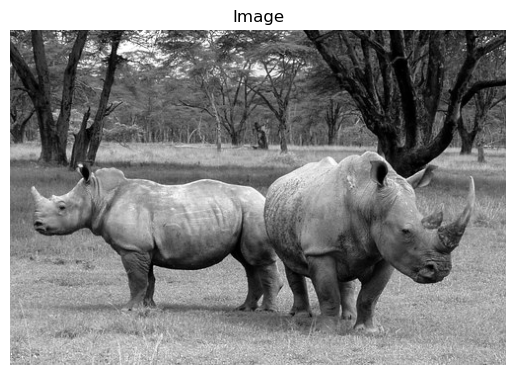

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

image = np.array(Image.open('test.jpg').convert('L')) 
plt.figure()
plt.imshow(image, cmap='gray')  
plt.axis('off')
plt.title("Image")
plt.show()

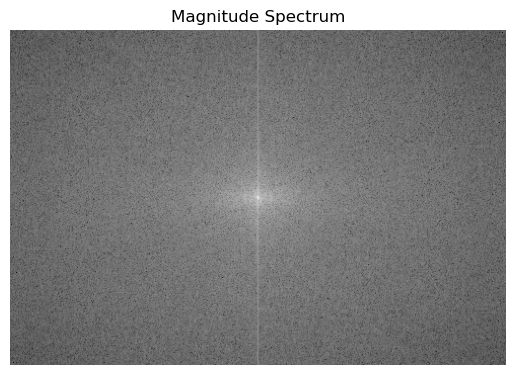

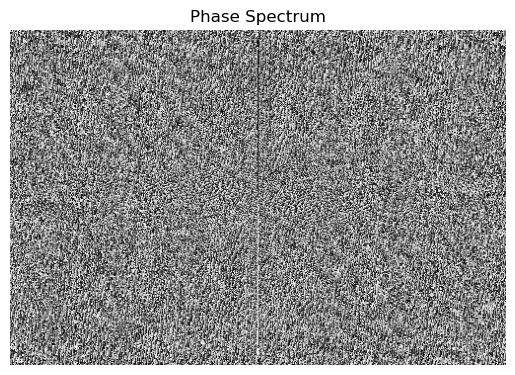

In [3]:
F = np.fft.fft2(image)

plt.figure()
plt.imshow(np.log1p(np.abs(np.fft.fftshift(F))), cmap='gray')  # log for visibility
plt.axis('off')
plt.title("Magnitude Spectrum")
plt.show()

plt.figure()
plt.imshow(np.angle(np.fft.fftshift(F)), cmap='gray')
plt.axis('off')
plt.title("Phase Spectrum")
plt.show()

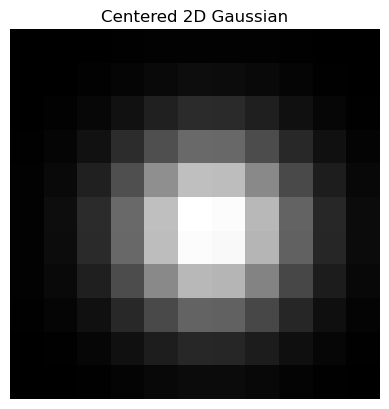

In [5]:
################## Gaussian Filter ##################
def create_centered_gaussian(L, sigma=20):
    xy = np.linspace(-L // 2, L // 2, L)    
    X, Y = np.meshgrid(xy, xy)    
    # 2D Gaussian formula
    gaussian = np.exp(-(X**2 + Y**2) / (2 * sigma**2))    
    # Normalize to range [0, 1]
    gaussian /= np.max(gaussian)    
    gaussian /= (L**2)
    return gaussian

# Example usage
gaussian_image = create_centered_gaussian(11, sigma=2)
plt.figure()
plt.imshow(gaussian_image, cmap='gray')
plt.title("Centered 2D Gaussian")
plt.axis("off")
plt.show()

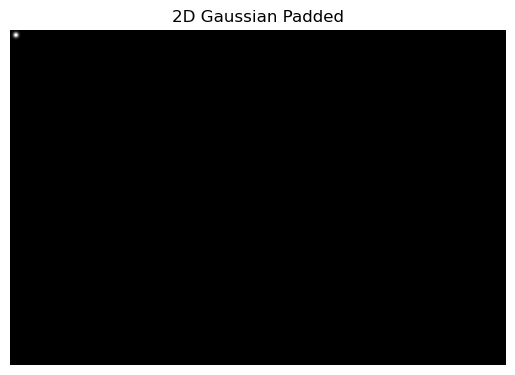

In [6]:
gaussian_image_padded = np.zeros(image.shape)
h, w = gaussian_image.shape
gaussian_image_padded[:h, :w] = gaussian_image
del h, w
plt.figure()
plt.imshow(gaussian_image_padded, cmap='gray')
plt.title("2D Gaussian Padded")
plt.axis("off")
plt.show()

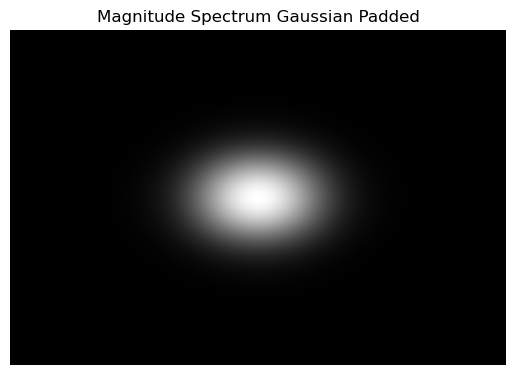

In [7]:
F_G = np.fft.fft2(gaussian_image_padded)
plt.figure()
plt.imshow(np.log1p(np.abs(np.fft.fftshift(F_G))), cmap='gray')  # log for visibility
plt.axis('off')
plt.title("Magnitude Spectrum Gaussian Padded")
plt.show()

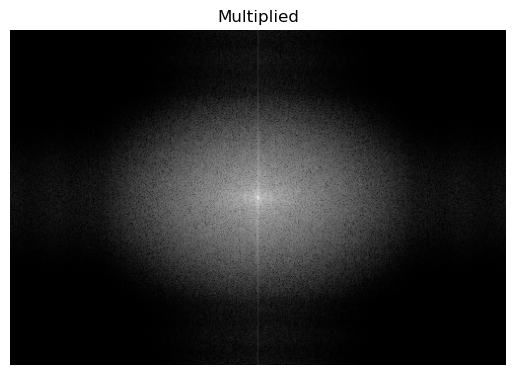

In [8]:
################ Multiplying Gaussian by Image ##############
multiplied = F*F_G
plt.figure()
plt.imshow(np.log1p(np.abs(np.fft.fftshift(multiplied))), cmap='gray')  # log for visibility
plt.axis('off')
plt.title("Multiplied")
plt.show()

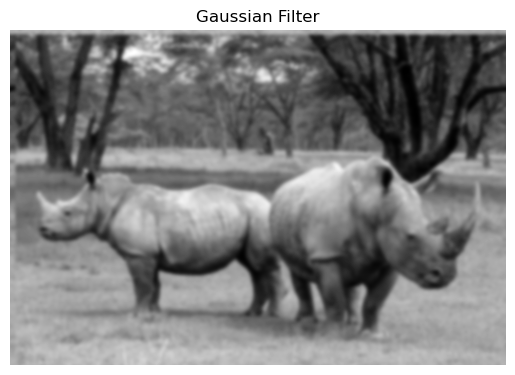

In [9]:
result = np.fft.ifft2(multiplied)
plt.figure()
plt.imshow(np.abs(result), cmap='gray') 
plt.axis('off')
plt.title("Gaussian Filter")
plt.show()